#Group-F
Members Name & Id
1.Sumaiya Hoque Riyan(2022-1-60-111)
2.Mahbub Hasan(2021-3-60-261)
3.Lima Prodhan(2021-3-60-180)

In [1]:
import os
import re
import time
import random
from pathlib import Path

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else []

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.filters import threshold_multiotsu
from skimage.morphology import remove_small_objects, skeletonize
from skimage.measure import label, regionprops

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)

CONFIG = {
    "dataset_hint": "/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024",
    "eval_max_images": 80,
    "preview_max_images": 6,
    "min_object_area": 25,
    "mask_threshold": 127,
    "generated_mask_dir": "/kaggle/working/",
    "overlay_dir": "/kaggle/working/",
}


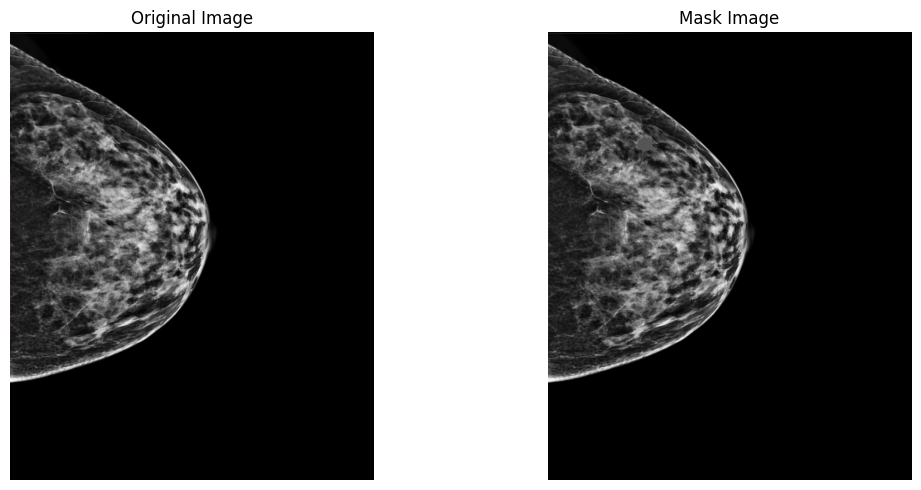


Image: /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P3/Left/Original Image/IMG-0001-00001.jpg
Mask : /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P3/Left/Mask Image/IMG-0001-00001 copy.jpg


In [2]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set"
)

pairs = []

for patient_dir in DATASET_ROOT.iterdir():

    if not patient_dir.is_dir():
        continue

    for side_dir in patient_dir.iterdir():

        if not side_dir.is_dir():
            continue

        original_dir = None
        mask_dir = None

        for sub in side_dir.iterdir():

            name = sub.name.lower()

            if "original" in name or "orignal" in name:
                original_dir = sub

            elif "mask" in name:
                mask_dir = sub

        if original_dir is None or mask_dir is None:
            continue

        imgs = sorted([
            p for p in original_dir.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
        ])

        masks = sorted([
            p for p in mask_dir.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
        ])

        for img_path, mask_path in zip(imgs, masks):
            pairs.append((img_path, mask_path))

img_path, mask_path = pairs[0]

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nImage:", img_path)
print("Mask :", mask_path)

In [3]:
from sklearn.model_selection import train_test_split

random_state = SEED

pairs_shuffled = random.sample(pairs, len(pairs))

train_pairs, remaining_pairs = train_test_split(
    pairs_shuffled,
    test_size=0.3,
    random_state=random_state,
)

val_pairs, test_pairs = train_test_split(
    remaining_pairs,
    test_size=0.5,
    random_state=random_state,
)

print(f"Train size: {len(train_pairs)}")
print(f"Validation size: {len(val_pairs)}")
print(f"Test size: {len(test_pairs)}")

train_df = pd.DataFrame(train_pairs, columns=["image", "mask"])
val_df = pd.DataFrame(val_pairs, columns=["image", "mask"])
test_df = pd.DataFrame(test_pairs, columns=["image", "mask"])

train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/validation.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

all_pairs = set([pair[0] for pair in pairs])
train_images = set(train_df["image"])
val_images = set(val_df["image"])
test_images = set(test_df["image"])

assert all_pairs == train_images.union(val_images).union(test_images), "Some images are missing"
assert len(train_images.intersection(val_images)) == 0, "Train and Validation overlap"
assert len(train_images.intersection(test_images)) == 0, "Train and Test overlap"
assert len(val_images.intersection(test_images)) == 0, "Validation and Test overlap"

print("Data split verified successfully!")


Train size: 1064
Validation size: 228
Test size: 229
Data split verified successfully!


In [4]:
rows = []
for patient_dir in sorted(DATASET_ROOT.iterdir()):
    if not patient_dir.is_dir():
        continue
    for side_dir in sorted(patient_dir.iterdir()):
        if not side_dir.is_dir():
            continue
        original_dir, mask_dir = None, None
        for sub in side_dir.iterdir():
            name = sub.name.lower()
            if "original" in name or "orignal" in name:
                original_dir = sub
            elif "mask" in name:
                mask_dir = sub
        if original_dir is None or mask_dir is None:
            continue

        imgs = sorted([p for p in original_dir.iterdir()
                        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]])
        masks = sorted([p for p in mask_dir.iterdir()
                         if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]])

        for img_path, mask_path in zip(imgs, masks):
            rows.append({
                "patient_id": patient_dir.name,
                "side": side_dir.name,
                "img_path": str(img_path),
                "mask_path": str(mask_path),
            })

df = pd.DataFrame(rows)
print(f"Total image-mask pairs: {len(df)}")
print(f"Total unique patients:  {df['patient_id'].nunique()}")
print(f"Sides found: {sorted(df['side'].unique())}")
df.head()


Total image-mask pairs: 1521
Total unique patients:  10
Sides found: ['Left', 'left', 'right']


,patient_id,side,img_path,mask_path
0,P1,left,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-...,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Mask Image/IMG-000...
1,P1,left,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-...,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Mask Image/IMG-000...
2,P1,left,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-...,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Mask Image/IMG-000...
3,P1,left,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-...,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Mask Image/IMG-000...
4,P1,left,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-...,/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Mask Image/IMG-000...


In [5]:
sample_n = min(60, len(df))
sample_rows = df.sample(sample_n, random_state=SEED)

unique_vals = set()
for mp in sample_rows["mask_path"]:
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    unique_vals.update(np.unique(m).tolist())

unique_vals = sorted(unique_vals)
print("Unique pixel values found across sample masks:", unique_vals[:20],
      "..." if len(unique_vals) > 20 else "")

is_likely_binary = len(unique_vals) <= 10 or (min(unique_vals) < 10 and max(unique_vals) > 200)
print("\nInterpretation:")
if is_likely_binary:
    print(f"-> Looks BINARY (background vs. lesion). "
          f"Will threshold at {CONFIG['mask_threshold']} to get a clean 0/1 mask.")
else:
    print("-> Looks like it may carry MORE than 2 classes or grayscale noise. "
          "Inspect further before assuming binary.")

Unique pixel values found across sample masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] ...

Interpretation:
-> Looks BINARY (background vs. lesion). Will threshold at 127 to get a clean 0/1 mask.


Scanning masks for pixel counts:   0%|          | 0/80 [00:00<?, ?it/s]

Sampled 80 masks (of 1521 total pairs)
Foreground (lesion) pixels: 3,797,319 (1.00%)
Background pixels:         376,566,041 (99.00%)


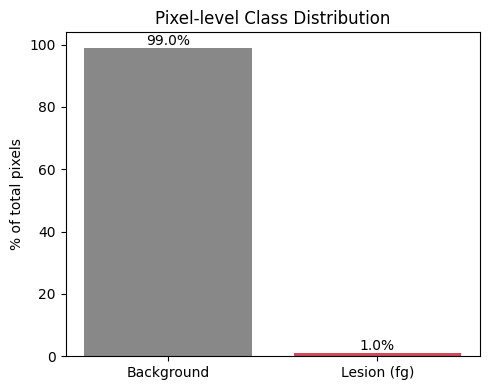

In [6]:
total_fg_pixels = 0
total_bg_pixels = 0

eval_subset = df.sample(min(CONFIG["eval_max_images"], len(df)), random_state=SEED)

for mp in tqdm(eval_subset["mask_path"], desc="Scanning masks for pixel counts"):
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    binary_m = (m >= CONFIG["mask_threshold"]).astype(np.uint8)
    total_fg_pixels += int(binary_m.sum())
    total_bg_pixels += int(binary_m.size - binary_m.sum())

total_pixels = total_fg_pixels + total_bg_pixels
fg_pct = 100 * total_fg_pixels / total_pixels
bg_pct = 100 * total_bg_pixels / total_pixels

print(f"Sampled {len(eval_subset)} masks (of {len(df)} total pairs)")
print(f"Foreground (lesion) pixels: {total_fg_pixels:,} ({fg_pct:.2f}%)")
print(f"Background pixels:         {total_bg_pixels:,} ({bg_pct:.2f}%)")

plt.figure(figsize=(5, 4))
plt.bar(["Background", "Lesion (fg)"], [bg_pct, fg_pct], color=["#888888", "#d1495b"])
plt.ylabel("% of total pixels")
plt.title("Pixel-level Class Distribution")
for i, v in enumerate([bg_pct, fg_pct]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

Reading image dimensions:   0%|          | 0/80 [00:00<?, ?it/s]

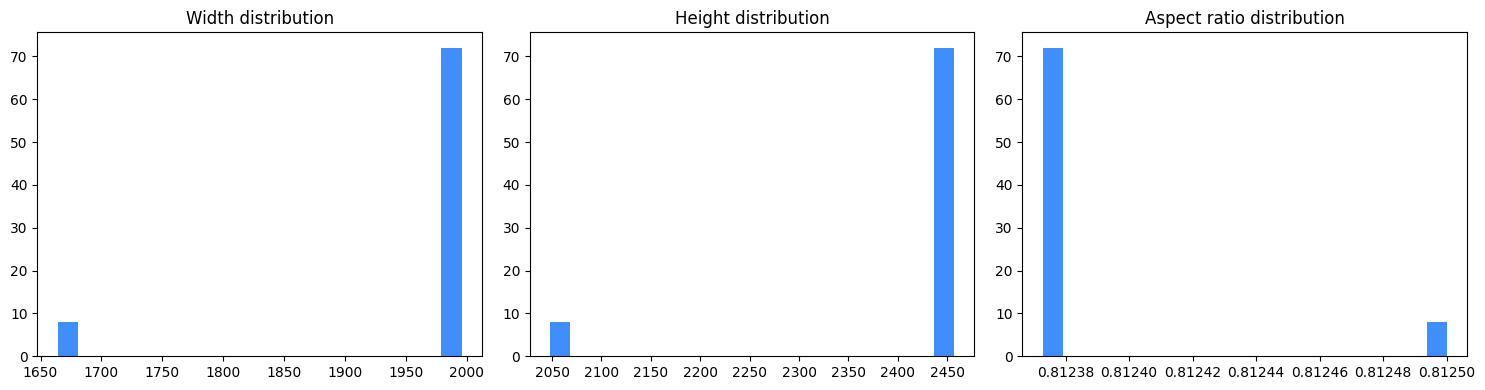

Width  range: 1664 - 1996  (unique sizes: 2)
Height range: 2048 - 2457 (unique sizes: 2)
Uniform resolution across sample: False


In [7]:
widths, heights = [], []
for ip in tqdm(eval_subset["img_path"], desc="Reading image dimensions"):
    im = cv2.imread(ip)
    if im is None:
        continue
    h, w = im.shape[:2]
    widths.append(w)
    heights.append(h)

aspect_ratios = [w / h for w, h in zip(widths, heights)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=20, color="#3f8efc")
axes[0].set_title("Width distribution")
axes[1].hist(heights, bins=20, color="#3f8efc")
axes[1].set_title("Height distribution")
axes[2].hist(aspect_ratios, bins=20, color="#3f8efc")
axes[2].set_title("Aspect ratio distribution")
plt.tight_layout()
plt.show()

print(f"Width  range: {min(widths)} - {max(widths)}  (unique sizes: {len(set(widths))})")
print(f"Height range: {min(heights)} - {max(heights)} (unique sizes: {len(set(heights))})")
uniform = (len(set(widths)) == 1 and len(set(heights)) == 1)
print(f"Uniform resolution across sample: {uniform}")

In [8]:
corrupted = []
mismatched_shape = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Validating all pairs"):
    im = cv2.imread(row["img_path"])
    mk = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    if im is None or mk is None:
        corrupted.append(row["img_path"] if im is None else row["mask_path"])
        continue
    if im.shape[:2] != mk.shape[:2]:
        mismatched_shape.append((row["img_path"], im.shape[:2], mk.shape[:2]))

print(f"Corrupted / unreadable files: {len(corrupted)}")
if corrupted:
    print(corrupted[:10])

print(f"Image-mask shape mismatches: {len(mismatched_shape)}")
if mismatched_shape:
    print(mismatched_shape[:10])

Validating all pairs:   0%|          | 0/1521 [00:00<?, ?it/s]

Corrupted / unreadable files: 0
Image-mask shape mismatches: 2
[('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0008-00015.jpg', (2048, 1664), (2457, 1996)), ('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P8/right/Orignal Image/IMG-0006-00015.jpg', (2048, 1664), (2457, 1996))]


Hashing images for near-duplicate check:   0%|          | 0/1521 [00:00<?, ?it/s]

Exact/near-duplicate candidates: 1270
[('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00001.jpg', '/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00002.jpg'), ('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00003.jpg', '/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00004.jpg'), ('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00003.jpg', '/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00005.jpg'), ('/kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P1/left/Orignal Image/IMG-0007-00003.jpg', '/kaggle/input/d

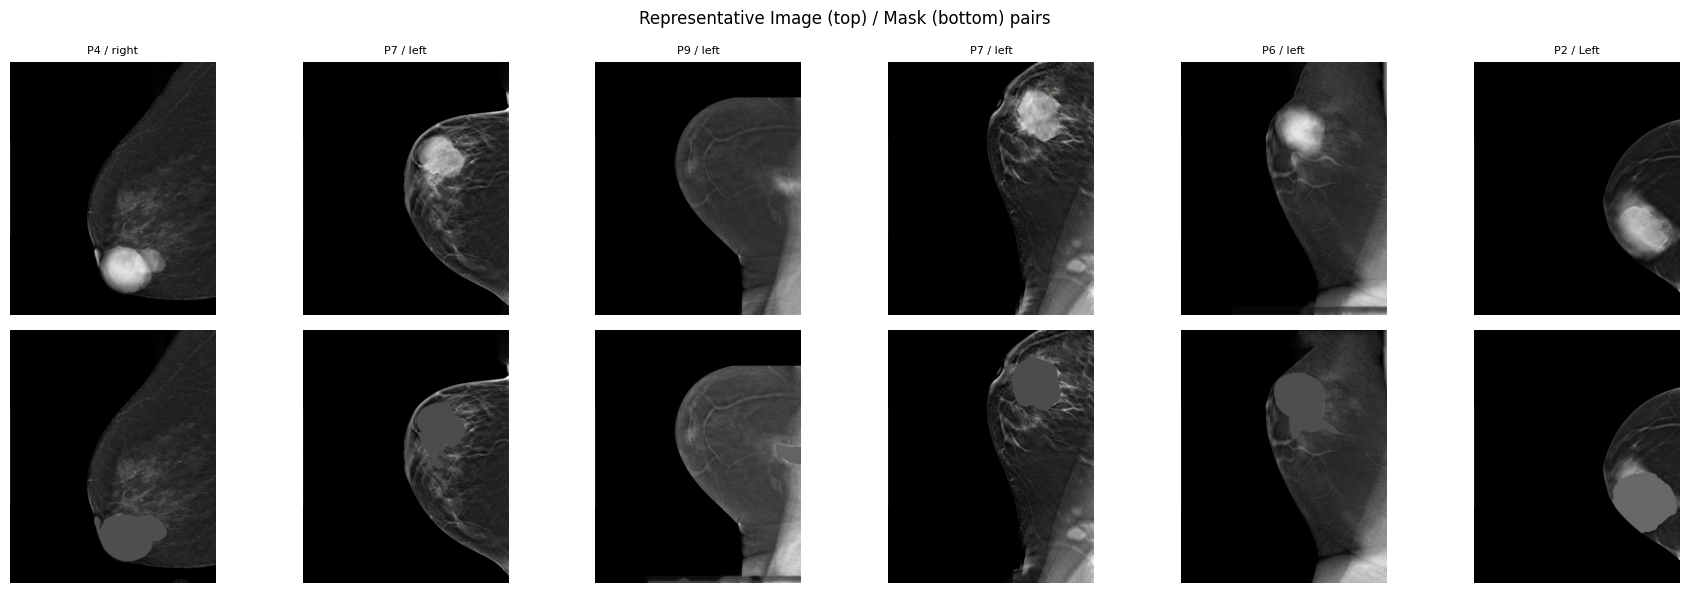

In [9]:
import hashlib

def phash_simple(path, hash_size=8):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (hash_size, hash_size))
    avg = img.mean()
    bits = (img > avg).flatten()
    return hashlib.md5(bits.tobytes()).hexdigest()

hashes = {}
duplicates = []
for ip in tqdm(df["img_path"], desc="Hashing images for near-duplicate check"):
    h = phash_simple(ip)
    if h in hashes:
        duplicates.append((hashes[h], ip))
    else:
        hashes[h] = ip

print(f"Exact/near-duplicate candidates: {len(duplicates)}")
if duplicates:
    print(duplicates[:10])
    
n_show = CONFIG["preview_max_images"]
show_rows = df.sample(n_show, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i, row in show_rows.iterrows():
    im = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    mk = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(im)
    axes[0, i].set_title(f"{row['patient_id']} / {row['side']}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(mk, cmap="gray")
    axes[1, i].axis("off")
plt.suptitle("Representative Image (top) / Mask (bottom) pairs")
plt.tight_layout()
plt.show()


In [10]:
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-6

patients = sorted(df["patient_id"].unique().tolist())
rng = random.Random(SEED)
rng.shuffle(patients)

n = len(patients)
train_end = int(round(TRAIN_FRAC * n))
val_end = train_end + int(round(VAL_FRAC * n))

train_patients = set(patients[:train_end])
val_patients = set(patients[train_end:val_end])
test_patients = set(patients[val_end:])

def assign_split(pid):
    if pid in train_patients:
        return "train"
    elif pid in val_patients:
        return "val"
    else:
        return "test"

df["split"] = df["patient_id"].apply(assign_split)

print("Patients per split:",
      {s: len(v) for s, v in [("train", train_patients), ("val", val_patients), ("test", test_patients)]})
print("\nImage pairs per split:")
print(df["split"].value_counts())
print(f"\nSeed used: {SEED}")
overlap_tv = train_patients & val_patients
overlap_tt = train_patients & test_patients
overlap_vt = val_patients & test_patients

assert not overlap_tv, f"LEAKAGE: patients in both train and val: {overlap_tv}"
assert not overlap_tt, f"LEAKAGE: patients in both train and test: {overlap_tt}"
assert not overlap_vt, f"LEAKAGE: patients in both val and test: {overlap_vt}"

print("PASS -- no patient appears in more than one split.")
print(f"Total patients accounted for: "
      f"{len(train_patients) + len(val_patients) + len(test_patients)} / {n}")


Patients per split: {'train': 7, 'val': 2, 'test': 1}

Image pairs per split:
split
train    1035
val       318
test      168
Name: count, dtype: int64

Seed used: 42
PASS -- no patient appears in more than one split.
Total patients accounted for: 10 / 10


In [11]:
split_path = os.path.join(CONFIG["generated_mask_dir"], "split.csv")
df.to_csv(split_path, index=False)
print(f"Saved split artifact -> {split_path}")

Saved split artifact -> /kaggle/working/split.csv


In [12]:
!pip install albumentations --upgrade

In [13]:
import albumentations as A

IMG_SIZE = 512  # confirm against your Cell 6 findings; resize if not uniform

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),          # no canonical left/right orientation in ultrasound
    A.VerticalFlip(p=0.3),            # safe: no "up" bias like street-view data
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # mimics probe/motion blur, mild only
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2), # mimics ultrasound speckle noise
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    # NOTE: no augmentation here -- val/test are resize-only by design (Task C rule)
])

print("Train pipeline steps:")
for t in train_transform.transforms:
    print(" -", t)

Train pipeline steps:
 - Resize(p=1.0, area_for_downscale=None, height=512, interpolation=1, mask_interpolation=0, width=512)
 - HorizontalFlip(p=0.5)
 - VerticalFlip(p=0.3)
 - RandomRotate90(p=0.3)
 - ShiftScaleRotate(p=0.4, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.09999999999999998, 0.10000000000000009), rotate_limit=(-15.0, 15.0), interpolation=1, border_mode=0, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0)
 - RandomBrightnessContrast(p=0.4, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), ensure_safe_range=False)
 - GaussianBlur(p=0.2, blur_limit=(3, 5), sigma_limit=(0.5, 3.0))
 - GaussNoise(p=0.2, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44))


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_24/3918407739.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2), # mimics ultrasound speckle noise


In [14]:
from torch.utils.data import Dataset

class SegDataset(Dataset):
    def __init__(self, dataframe, transform=None, mask_threshold=CONFIG["mask_threshold"]):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mask_threshold = mask_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask >= self.mask_threshold).astype(np.uint8)  # binarize to {0,1}

        if self.transform is not None:
            # Albumentations applies the SAME sampled random transform
            # to both image and mask in a single call -- this is what
            # guarantees synchronization (the thing you'll be asked
            # about at viva).
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        return img, mask

train_ds = SegDataset(df[df["split"] == "train"], transform=train_transform)
val_ds   = SegDataset(df[df["split"] == "val"],   transform=val_test_transform)
test_ds  = SegDataset(df[df["split"] == "test"],  transform=val_test_transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1035 | Val: 318 | Test: 168


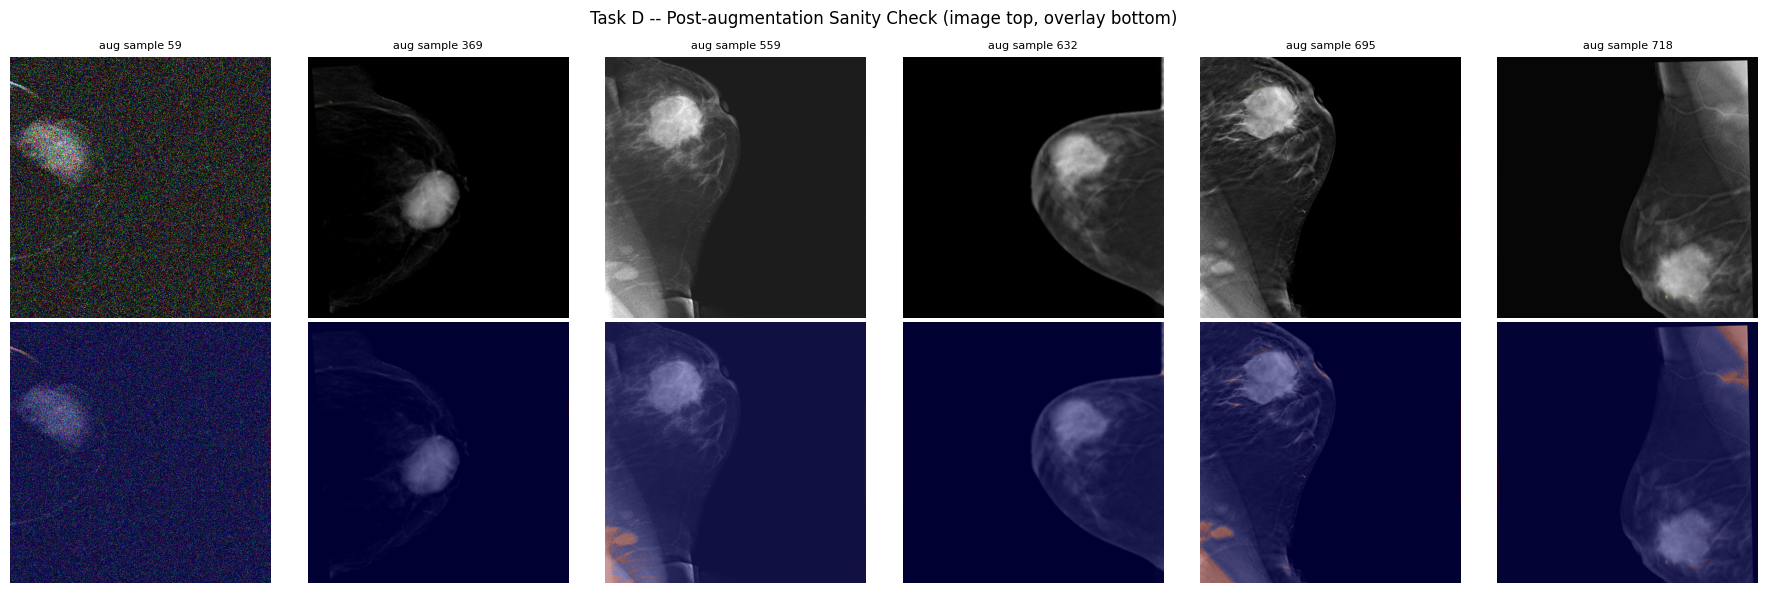

Confirm visually before proceeding to NB1:
 1. Mask overlay aligns with the lesion region in the image (no shift/flip mismatch)
 2. Mask coloring is consistent across samples
 3. No sample shows a destroyed/empty mask from augmentation


In [15]:
n_check = 6
fig, axes = plt.subplots(2, n_check, figsize=(3 * n_check, 6))

check_idxs = random.sample(range(len(train_ds)), min(n_check, len(train_ds)))
for col, idx in enumerate(check_idxs):
    img, mask = train_ds[idx]
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"aug sample {idx}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(mask, cmap="jet", alpha=0.4)  # overlay
    axes[1, col].axis("off")

plt.suptitle("Task D -- Post-augmentation Sanity Check (image top, overlay bottom)")
plt.tight_layout()
plt.show()

print("Confirm visually before proceeding to NB1:")
print(" 1. Mask overlay aligns with the lesion region in the image (no shift/flip mismatch)")
print(" 2. Mask coloring is consistent across samples")
print(" 3. No sample shows a destroyed/empty mask from augmentation")